In [1]:
from google.colab import files
uploaded = files.upload()

Saving Brain Tumor Dataset.zip to Brain Tumor Dataset.zip


In [2]:
import zipfile
import os

with zipfile.ZipFile("Brain Tumor Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("Brain_Tumor_Dataset")

os.listdir("Brain_Tumor_Dataset")

['Testing', 'Training']

In [3]:
train_dir = "Brain_Tumor_Dataset/Training"
test_dir = "Brain_Tumor_Dataset/Testing"

print("Training Folders:", os.listdir(train_dir))
print("Testing Folders:", os.listdir(test_dir))

Training Folders: ['meningioma', 'glioma', 'pituitary', 'notumor']
Testing Folders: ['meningioma', 'glioma', 'pituitary', 'notumor']


In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import cv2, warnings
warnings.filterwarnings('ignore')

Data Preprocessing

In [5]:
img_size = (128, 128)
batch_size = 32

In [8]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)
train_generator = train_gen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", subset="training"
)

Found 4571 images belonging to 4 classes.


In [9]:
val_generator = train_gen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", subset="validation"
)

Found 1141 images belonging to 4 classes.


In [10]:
test_gen = ImageDataGenerator(rescale=1./255)
test_generator = test_gen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", shuffle=False
)

Found 1311 images belonging to 4 classes.


In [13]:
for class_name, index in train_generator.class_indices.items():
    count = sum(train_generator.classes == index)
    print(f"{class_name}: {count} images")

glioma: 1057 images
meningioma: 1072 images
notumor: 1276 images
pituitary: 1166 images


Batch images shape: (32, 128, 128, 3)
Batch labels shape: (32, 4)


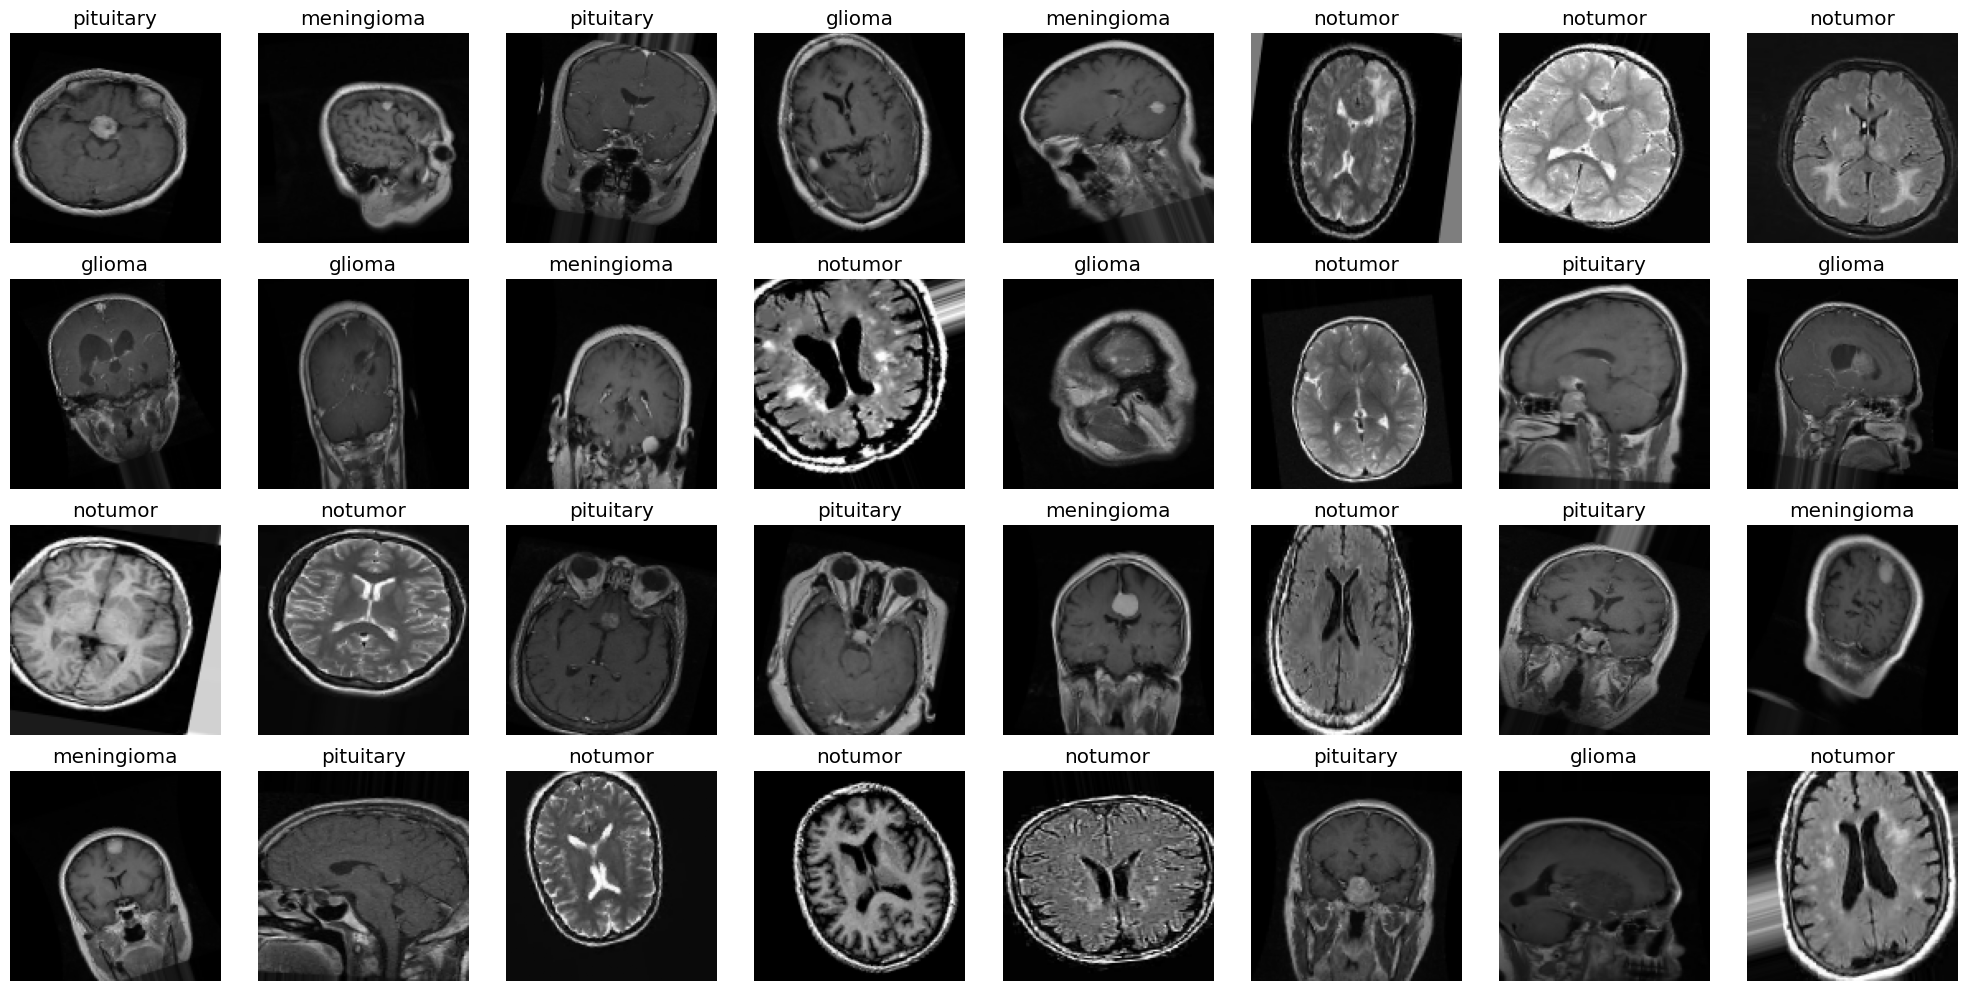

In [14]:
# Take one batch
images, labels = next(train_generator)

print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)

# Show the batch
plt.figure(figsize=(20, 10))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.imshow(images[i])  # float images already in [0,1], so no need to cast
    plt.title(list(train_generator.class_indices.keys())[np.argmax(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

CNN Baseline Model

In [16]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(4, activation="softmax")
])

cnn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"])


In [19]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.keras", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]


history_cnn = cnn_model.fit(
    train_generator, validation_data=val_generator,
    epochs=20, callbacks=callbacks
)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.6306 - loss: 1.0653 - val_accuracy: 0.2594 - val_loss: 3.3555 - learning_rate: 1.0000e-04
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.7324 - loss: 0.6652 - val_accuracy: 0.2612 - val_loss: 3.4970 - learning_rate: 1.0000e-04
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.7792 - loss: 0.5585 - val_accuracy: 0.4557 - val_loss: 1.5776 - learning_rate: 1.0000e-04
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.7958 - loss: 0.5238 - val_accuracy: 0.6608 - val_loss: 0.8858 - learning_rate: 1.0000e-04
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.8248 - loss: 0.4508 - val_accuracy: 0.7099 - val_loss: 0.7566 - learning_rate: 1.0000e-04
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.8214 - loss: 0.4497 - val_accuracy: 0.7730 - val_loss: 0.6221 - learning_rate: 1.0000e-04
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - acc

Transfer Learning - VGG16

In [26]:
base_vgg = VGG16(weights="imagenet", include_top=False, input_shape=(128,128,3))
for layer in base_vgg.layers:
    layer.trainable = False

x = layers.Flatten()(base_vgg.output)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation="softmax")(x)

vgg_model = Model(inputs=base_vgg.input, outputs=output)
vgg_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"])


history_vgg = vgg_model.fit(
    train_generator, validation_data=val_generator,
    epochs=15, callbacks=callbacks
)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1171s 8s/step - accuracy: 0.5883 - loss: 0.9906 - val_accuracy: 0.6599 - val_loss: 0.9313 - learning_rate: 1.0000e-04
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1129s 8s/step - accuracy: 0.8049 - loss: 0.5206 - val_accuracy: 0.7064 - val_loss: 0.7798 - learning_rate: 1.0000e-04
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1132s 8s/step - accuracy: 0.8187 - loss: 0.4778 - val_accuracy: 0.7064 - val_loss: 0.7560 - learning_rate: 1.0000e-04
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1169s 8s/step - accuracy: 0.8352 - loss: 0.4326 - val_accuracy: 0.7336 - val_loss: 0.7005 - learning_rate: 1.0000e-04
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1135s 8s/step - accuracy: 0.8542 - loss: 0.3926 - val_accuracy: 0.7257 - val_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1170s 8s/step - accuracy: 0.8619 - loss: 0.3771 - val_accuracy: 0.7502 - val_loss: 0.6442 - learning_rate: 1.0000e-04
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 1135s 8s/ste

Transfer Learning - ResNet50

In [22]:
base_resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(128,128,3))
for layer in base_resnet.layers:
    layer.trainable = False

y = layers.GlobalAveragePooling2D()(base_resnet.output)
y = layers.Dense(256, activation="relu")(y)
y = layers.Dropout(0.5)(y)
output_resnet = layers.Dense(4, activation="softmax")(y)

resnet_model = Model(inputs=base_resnet.input, outputs=output_resnet)
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                     loss="categorical_crossentropy", metrics=["accuracy"])


history_resnet = resnet_model.fit(
    train_generator, validation_data=val_generator,
    epochs=15, callbacks=callbacks
)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.2741 - loss: 1.4926 - val_accuracy: 0.4479 - val_loss: 1.3339 - learning_rate: 1.0000e-04
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.3545 - loss: 1.3453 - val_accuracy: 0.3471 - val_loss: 1.3038 - learning_rate: 1.0000e-04
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.3788 - loss: 1.2805 - val_accuracy: 0.4733 - val_loss: 1.2838 - learning_rate: 1.0000e-04
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 361s 3s/step - accuracy: 0.4186 - loss: 1.2365 - val_accuracy: 0.4812 - val_loss: 1.2670 - learning_rate: 1.0000e-04
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.4458 - loss: 1.2068 - val_accuracy: 0.4619 - val_loss: 1.2607 - learning_rate: 1.0000e-04
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.4737 - loss: 1.1672 - val_accuracy: 0.4750 - val_loss: 1.2436 - learning_rate: 1.0000e-04
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - acc

Evaluation Function

In [29]:
def evaluate_model(model, name):
    print(f"\nEvaluating {name}")
    loss, acc = model.evaluate(test_generator)
    print(f"{name} Test Accuracy: {acc*100:.2f}%")

    y_pred_prob = model.predict(test_generator)
    y_true = test_generator.classes
    y_pred = np.argmax(y_pred_prob, axis=1)

    print("Classification Report:\n", classification_report(
        y_true, y_pred, target_names=list(test_generator.class_indices.keys())
    ))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    # ROC Curves
    plt.figure(figsize=(8,6))
    for i, class_name in enumerate(test_generator.class_indices.keys()):
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title(f"ROC Curves - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

Evaluate All Models


Evaluating CNN Baseline
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 438ms/step - accuracy: 0.6753 - loss: 0.9940
CNN Baseline Test Accuracy: 79.79%
41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 406ms/step
Classification Report:
               precision    recall  f1-score   support

      glioma       0.98      0.65      0.78       300
  meningioma       0.79      0.49      0.60       306
     notumor       0.80      0.99      0.89       405
   pituitary       0.71      1.00      0.83       300

    accuracy                           0.80      1311
   macro avg       0.82      0.78      0.78      1311
weighted avg       0.82      0.80      0.78      1311

Confusion Matrix:
 [[195  40   9  56]
 [  4 149  89  64]
 [  0   0 402   3]
 [  0   0   0 300]]


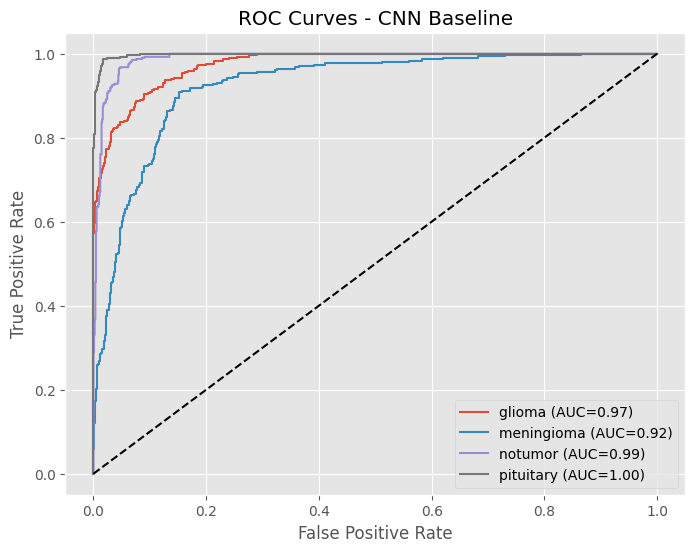


Evaluating VGG16 Transfer Learning
41/41 ━━━━━━━━━━━━━━━━━━━━ 255s 6s/step - accuracy: 0.7340 - loss: 0.6758
VGG16 Transfer Learning Test Accuracy: 81.85%
41/41 ━━━━━━━━━━━━━━━━━━━━ 255s 6s/step
Classification Report:
               precision    recall  f1-score   support

      glioma       0.88      0.76      0.82       300
  meningioma       0.80      0.52      0.63       306
     notumor       0.83      0.97      0.89       405
   pituitary       0.77      0.99      0.86       300

    accuracy                           0.82      1311
   macro avg       0.82      0.81      0.80      1311
weighted avg       0.82      0.82      0.81      1311

Confusion Matrix:
 [[228  36  16  20]
 [ 23 158  61  64]
 [  6   3 391   5]
 [  2   1   1 296]]


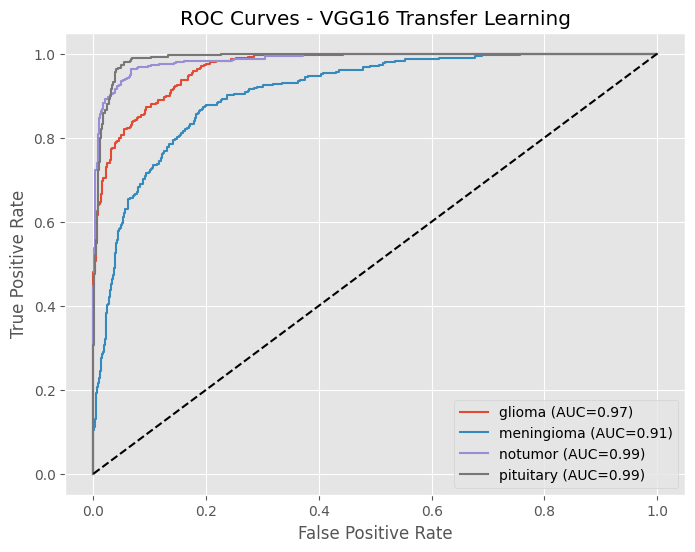


Evaluating ResNet50 Transfer Learning
41/41 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.3314 - loss: 1.4180
ResNet50 Transfer Learning Test Accuracy: 51.64%
41/41 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step
Classification Report:
               precision    recall  f1-score   support

      glioma       0.63      0.18      0.28       300
  meningioma       0.49      0.32      0.39       306
     notumor       0.53      0.84      0.65       405
   pituitary       0.48      0.62      0.54       300

    accuracy                           0.52      1311
   macro avg       0.53      0.49      0.46      1311
weighted avg       0.53      0.52      0.48      1311

Confusion Matrix:
 [[ 53  88  55 104]
 [  9  99 148  50]
 [ 21   1 339  44]
 [  1  15  98 186]]


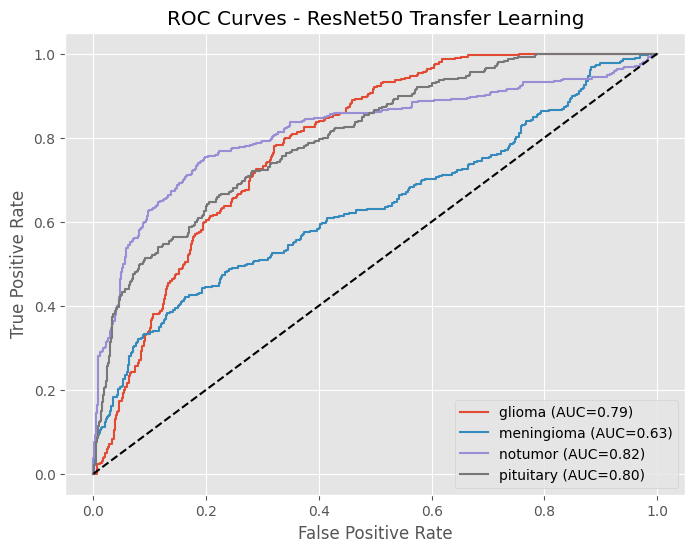

In [30]:
evaluate_model(cnn_model, "CNN Baseline")
evaluate_model(vgg_model, "VGG16 Transfer Learning")
evaluate_model(resnet_model, "ResNet50 Transfer Learning")

Training Curves

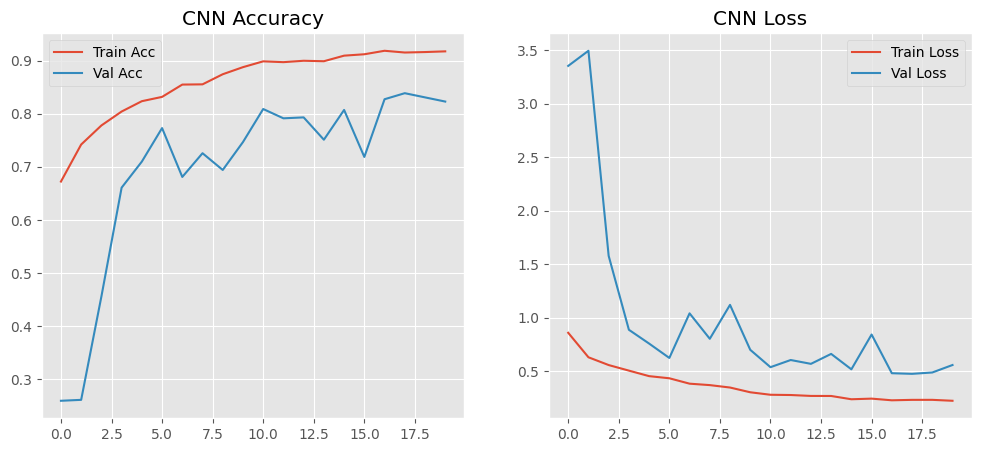

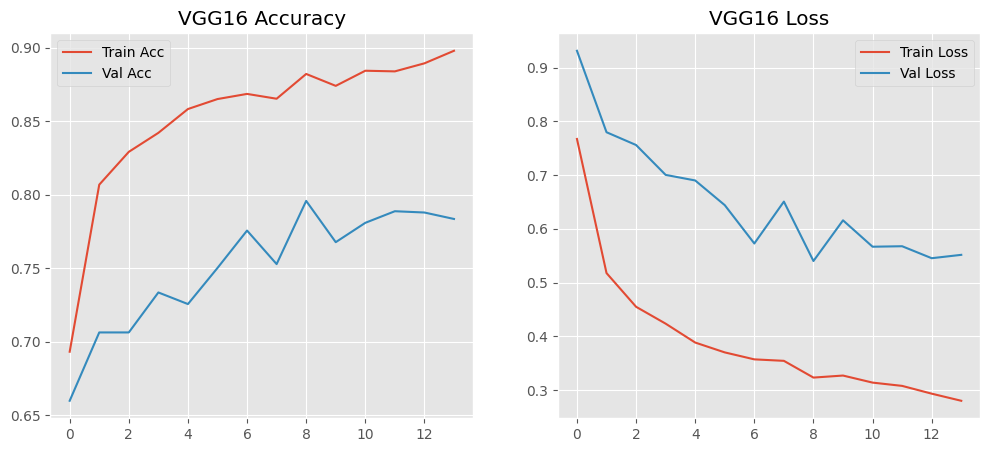

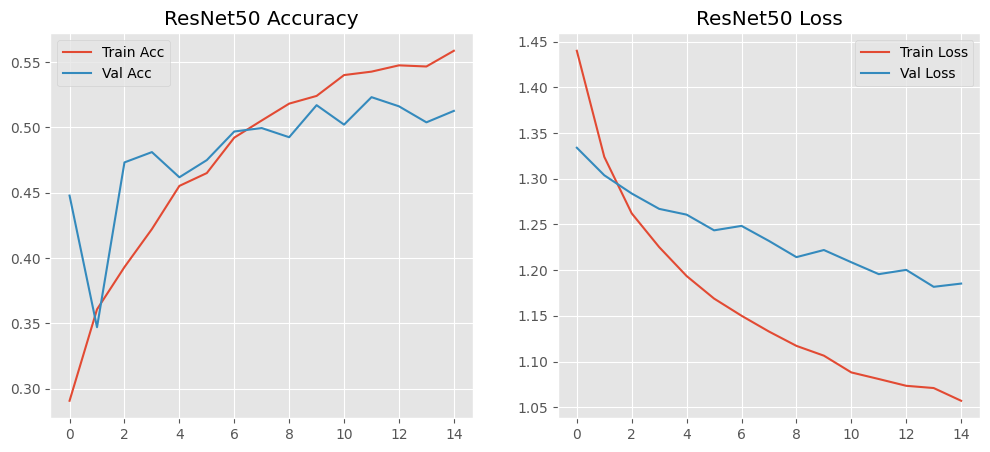

In [31]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train Acc")
    plt.plot(history.history['val_accuracy'], label="Val Acc")
    plt.legend(); plt.title(f"{title} Accuracy")

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    plt.legend(); plt.title(f"{title} Loss")

    plt.show()

plot_history(history_cnn, "CNN")
plot_history(history_vgg, "VGG16")
plot_history(history_resnet, "ResNet50")